In [ ]:
import json
import re
import pandas as pd

# Parâmetros máximos (ajuste conforme necessário)
PARAMS_MAX = {'p1', 'p2', 'p3', 'p4', 'p5'}

def extract_params(expr):
    return set(re.findall(r'p\d+', expr))

def riqueza_set(params):
    return len(params) / len(PARAMS_MAX) if PARAMS_MAX else 0

def riqueza_given(scenario):
    return riqueza_set(extract_params(scenario.get('given', '')))

def riqueza_then(scenario):
    return riqueza_set(extract_params(scenario.get('then', '')))

def riqueza_total(scenario):
    given_params = extract_params(scenario.get('given', ''))
    then_params = extract_params(scenario.get('then', ''))
    params_total = given_params.union(then_params)
    return riqueza_set(params_total)

def categoriza_similaridade(valor):
    if valor < 0.2:
        return 'baixa'
    elif valor < 0.4:
        return 'baixa-média'
    elif valor < 0.6:
        return 'média'
    elif valor < 0.8:
        return 'média-alta'
    else:
        return 'alta'

# Lista para armazenar os resultados
registros = []

with open('similarity_results.jsonl', 'r', encoding='utf-8') as f:
    for line in f:
        data = json.loads(line)
        diagnosed = data['diagnosed']
        candidate = data['candidate']
        similarity = data['similarity_result']

        # Parâmetros dos cenários
        params_given_diagnosed = extract_params(diagnosed.get('given', ''))
        params_then_diagnosed = extract_params(diagnosed.get('then', ''))
        params_given_candidate = extract_params(candidate.get('given', ''))
        params_then_candidate = extract_params(candidate.get('then', ''))

        params_diagnosed_total = params_given_diagnosed | params_then_diagnosed
        params_candidate_total = params_given_candidate | params_then_candidate

        # Calcula a interseção dos parâmetros totais
        intersecao_parametros = len(params_diagnosed_total & params_candidate_total)
        # (Opcional) lista dos parâmetros em comum
        intersecao_lista = sorted(params_diagnosed_total & params_candidate_total)

        # Riquezas detalhadas
        riqueza_given_diagnosed = riqueza_set(params_given_diagnosed)
        riqueza_then_diagnosed = riqueza_set(params_then_diagnosed)
        riqueza_given_candidate = riqueza_set(params_given_candidate)
        riqueza_then_candidate = riqueza_set(params_then_candidate)
        riqueza_diagnosed_total = riqueza_set(params_diagnosed_total)
        riqueza_candidate_total = riqueza_set(params_candidate_total)

        registros.append({
            'diagnosed_name': diagnosed['name'],
            'candidate_name': candidate['name'],
            'similarity_result': similarity,
            'riqueza_given_diagnosed': riqueza_given_diagnosed,
            'riqueza_then_diagnosed': riqueza_then_diagnosed,
            'riqueza_given_candidate': riqueza_given_candidate,
            'riqueza_then_candidate': riqueza_then_candidate,
            'riqueza_diagnosed': riqueza_diagnosed_total,
            'riqueza_candidate': riqueza_candidate_total,
            'params_given_diagnosed': sorted(params_given_diagnosed),
            'params_then_diagnosed': sorted(params_then_diagnosed),
            'params_given_candidate': sorted(params_given_candidate),
            'params_then_candidate': sorted(params_then_candidate),
            'intersecao_parametros': intersecao_parametros,
            'intersecao_lista': intersecao_lista
        })

# Criação do DataFrame
df = pd.DataFrame(registros)

# Categoria de similaridade
df['categoria_similaridade'] = df['similarity_result'].apply(categoriza_similaridade)

# Visualize as primeiras linhas
print(df.head())

# (Opcional) Salvar para csv
# df.to_csv('analise_similarity_granular.csv', index=False)


,diagnosed_name,candidate_name,similarity_result,riqueza_given_diagnosed,riqueza_then_diagnosed,riqueza_given_candidate,riqueza_then_candidate,riqueza_diagnosed,riqueza_candidate,params_given_diagnosed,params_then_diagnosed,params_given_candidate,params_then_candidate,categoria_similaridade
0,diagnosed1,diagnosed1,1.000000,0.2,0.2,0.2,0.2,0.4,0.4,[p1],[p2],[p1],[p2],alta
1,diagnosed1,diagnosed2,0.666667,0.2,0.2,0.2,0.2,0.4,0.4,[p1],[p2],[p1],[p3],média-alta
2,diagnosed1,diagnosed3,0.666667,0.2,0.2,0.2,0.2,0.4,0.4,[p1],[p2],[p1],[p4],média-alta
3,diagnosed1,diagnosed4,0.666667,0.2,0.2,0.2,0.2,0.4,0.4,[p1],[p2],[p1],[p5],média-alta
4,diagnosed1,diagnosed5,0.969697,0.2,0.2,0.2,0.4,0.4,0.6,[p1],[p2],[p1],"[p2, p3]",alta
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32395,diagnosed180,diagnosed176,0.583333,0.8,0.2,0.8,0.2,1.0,1.0,"[p2, p3, p4, p5]",[p1],"[p1, p2, p3, p4]",[p5],média
32396,diagnosed180,diagnosed177,0.583333,0.8,0.2,0.8,0.2,1.0,1.0,"[p2, p3, p4, p5]",[p1],"[p1, p2, p3, p5]",[p4],média
32397,diagnosed180,diagnosed178,0.583333,0.8,0.2,0.8,0.2,1.0,1.0,"[p2, p3, p4, p5]",[p1],"[p1, p2, p4, p5]",[p3],média
32398,diagnosed180,diagnosed179,0.583333,0.8,0.2,0.8,0.2,1.0,1.0,"[p2, p3, p4, p5]",[p1],"[p1, p3, p4, p5]",[p2],média


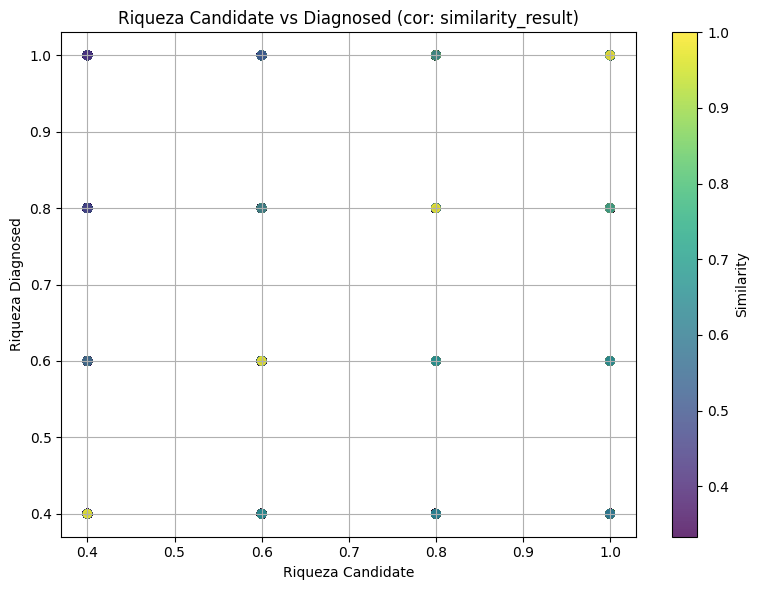

In [83]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# Agora: eixo X = riqueza_candidate, eixo Y = riqueza_diagnosed
scatter = plt.scatter(
    df['riqueza_candidate'],
    df['riqueza_diagnosed'],
    c=df['similarity_result'],
    cmap='viridis',
    alpha=0.8
)

plt.xlabel('Riqueza Candidate')
plt.ylabel('Riqueza Diagnosed')
plt.title('Riqueza Candidate vs Diagnosed (cor: similarity_result)')
plt.colorbar(scatter, label='Similarity')
plt.grid(True)
plt.tight_layout()
plt.show()


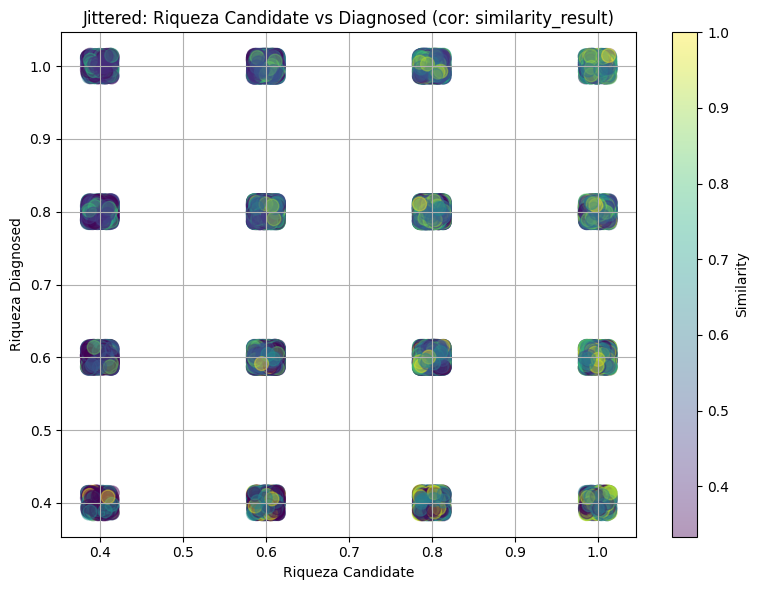

In [84]:
import numpy as np

jitter_strength = 0.015  # Ajuste conforme o espaçamento do seu grid
x = df['riqueza_candidate'] + np.random.uniform(-jitter_strength, jitter_strength, len(df))
y = df['riqueza_diagnosed'] + np.random.uniform(-jitter_strength, jitter_strength, len(df))

plt.figure(figsize=(8,6))
scatter = plt.scatter(
    x, y,
    c=df['similarity_result'],
    cmap='viridis',
    alpha=0.4,
    s=100
)
plt.xlabel('Riqueza Candidate')
plt.ylabel('Riqueza Diagnosed')
plt.title('Jittered: Riqueza Candidate vs Diagnosed (cor: similarity_result)')
plt.colorbar(scatter, label='Similarity')
plt.grid(True)
plt.tight_layout()
plt.show()


In [95]:
import numpy as np
import plotly.graph_objects as go

pivot_surface = df.pivot_table(
    index='riqueza_diagnosed',
    columns='riqueza_candidate',
    values='similarity_result',
    aggfunc='mean'  # Ou 'median'
).sort_index().sort_index(axis=1)

x = pivot_surface.columns.values      # riqueza_candidate
y = pivot_surface.index.values        # riqueza_diagnosed
z = pivot_surface.values              # similaridade média

fig = go.Figure(data=[
    go.Surface(
        z=z,
        x=x,
        y=y,
        colorscale='Viridis',
        colorbar=dict(title='Similaridade'),
        opacity=0.96,
        showscale=True,
        contours={
            "x": {"show": True, "color":"black", "width":2},
            "y": {"show": True, "color":"black", "width":2},
            "z": {"show": True, "color":"black", "width":2}
        }
    )
])

fig.update_layout(
    title='Surface 3D com Rede: Similaridade por Par de Riqueza',
    scene=dict(
        xaxis_title='Riqueza Candidate',
        yaxis_title='Riqueza Diagnosed',
        zaxis_title='Similaridade mediana'
    ),
    autosize=True,
    margin=dict(l=50, r=50, b=65, t=90),
)

fig.show()



In [94]:
import numpy as np
import plotly.graph_objects as go

pivot_surface = df.pivot_table(
    index='riqueza_diagnosed',
    columns='riqueza_candidate',
    values='similarity_result',
    aggfunc='median'  # Ou 'median'
).sort_index().sort_index(axis=1)

x = pivot_surface.columns.values      # riqueza_candidate
y = pivot_surface.index.values        # riqueza_diagnosed
z = pivot_surface.values              # similaridade média

fig = go.Figure(data=[
    go.Surface(
        z=z,
        x=x,
        y=y,
        colorscale='Viridis',
        colorbar=dict(title='Similaridade'),
        opacity=0.96,
        showscale=True,
        contours={
            "x": {"show": True, "color":"black", "width":2},
            "y": {"show": True, "color":"black", "width":2},
            "z": {"show": True, "color":"black", "width":2}
        }
    )
])

fig.update_layout(
    title='Surface 3D com Rede: Similaridade por Par de Riqueza',
    scene=dict(
        xaxis_title='Riqueza Candidate',
        yaxis_title='Riqueza Diagnosed',
        zaxis_title='Similaridade mediana'
    ),
    autosize=True,
    margin=dict(l=50, r=50, b=65, t=90),
)

fig.show()



In [104]:
filtro

,diagnosed_name,candidate_name,similarity_result,riqueza_given_diagnosed,riqueza_then_diagnosed,riqueza_given_candidate,riqueza_then_candidate,riqueza_diagnosed,riqueza_candidate,params_given_diagnosed,params_then_diagnosed,params_given_candidate,params_then_candidate,categoria_similaridade,categoria_similaridade_num
10,diagnosed1,diagnosed11,0.944444,0.2,0.2,0.2,0.6,0.4,0.8,[p1],[p2],[p1],"[p2, p3, p4]",alta,4
11,diagnosed1,diagnosed12,0.944444,0.2,0.2,0.2,0.6,0.4,0.8,[p1],[p2],[p1],"[p2, p3, p5]",alta,4
12,diagnosed1,diagnosed13,0.944444,0.2,0.2,0.2,0.6,0.4,0.8,[p1],[p2],[p1],"[p2, p4, p5]",alta,4
13,diagnosed1,diagnosed14,0.666667,0.2,0.2,0.2,0.6,0.4,0.8,[p1],[p2],[p1],"[p3, p4, p5]",média-alta,3
25,diagnosed1,diagnosed26,0.333333,0.2,0.2,0.2,0.6,0.4,0.8,[p1],[p2],[p2],"[p1, p3, p4]",baixa-média,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32387,diagnosed180,diagnosed168,0.589744,0.8,0.2,0.6,0.2,1.0,0.8,"[p2, p3, p4, p5]",[p1],"[p2, p3, p5]",[p4],média,2
32389,diagnosed180,diagnosed170,0.923077,0.8,0.2,0.6,0.2,1.0,0.8,"[p2, p3, p4, p5]",[p1],"[p2, p4, p5]",[p1],alta,4
32390,diagnosed180,diagnosed171,0.589744,0.8,0.2,0.6,0.2,1.0,0.8,"[p2, p3, p4, p5]",[p1],"[p2, p4, p5]",[p3],média,2
32392,diagnosed180,diagnosed173,0.923077,0.8,0.2,0.6,0.2,1.0,0.8,"[p2, p3, p4, p5]",[p1],"[p3, p4, p5]",[p1],alta,4


In [103]:
import plotly.graph_objects as go
import pandas as pd

# Garante que filtro está correto
filtro = df[df['riqueza_candidate'] == 0.8]

# Calcula a média de similaridade para cada valor de riqueza_diagnosed
media_sim = (
    filtro.groupby('riqueza_diagnosed')['similarity_result']
    .median()
    .reset_index()
    .sort_values('riqueza_diagnosed')
)

fig = go.Figure()

# Scatterplot dos pontos
fig.add_trace(
    go.Scatter(
        x=filtro['riqueza_diagnosed'],
        y=filtro['similarity_result'],
        mode='markers',
        marker=dict(
            size=13,
            color=filtro['similarity_result'],
            colorscale='Viridis',
            showscale=True,
            colorbar=dict(title='Similaridade')
        ),
        text=[
            f"""
            Diagnosed:<br>
            Given: {given_d}<br>
            Then: {then_d}<br>
            <br>
            Candidate:<br>
            Given: {given_c}<br>
            Then: {then_c}
            """
            for given_d, then_d, given_c, then_c in zip(
                filtro['params_given_diagnosed'],
                filtro['params_then_diagnosed'],
                filtro['params_given_candidate'],
                filtro['params_then_candidate']
            )
        ],
        hovertemplate=
            "Riqueza Diagnosed: %{x}<br>"+
            "Similaridade: %{y:.2f}<br><br>"+
            "%{text}<extra></extra>",
        name='Similaridade'
    )
)

# Linha de tendência (média)
fig.add_trace(
    go.Scatter(
        x=media_sim['riqueza_diagnosed'],
        y=media_sim['similarity_result'],
        mode='lines+markers',
        line=dict(color='red', width=3, dash='dash'),
        marker=dict(size=10, color='red'),
        name='Tendência (média)'
    )
)

fig.update_layout(
    title='Scatterplot: Similaridade vs Riqueza Diagnosed<br>(riqueza_candidate = 0.8)',
    xaxis_title='Riqueza Diagnosed',
    yaxis_title='Similaridade',
    template='plotly_white',
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01)
)

fig.show()


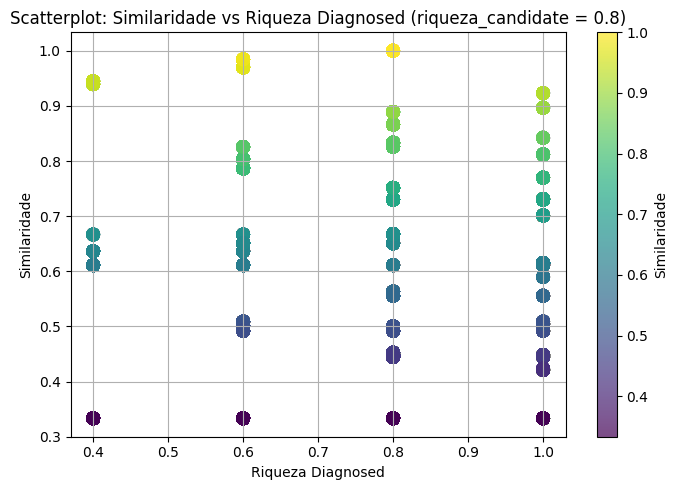

In [101]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))
plt.scatter(
    filtro['riqueza_diagnosed'],
    filtro['similarity_result'],
    c=filtro['similarity_result'],
    cmap='viridis',
    s=80,
    alpha=0.7
)
plt.xlabel('Riqueza Diagnosed')
plt.ylabel('Similaridade')
plt.title('Scatterplot: Similaridade vs Riqueza Diagnosed (riqueza_candidate = 0.8)')
plt.colorbar(label='Similaridade')
plt.grid(True)
plt.tight_layout()
plt.show()


C:\Users\lucas_alves\AppData\Local\Temp\ipykernel_98464\3240034678.py:58: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



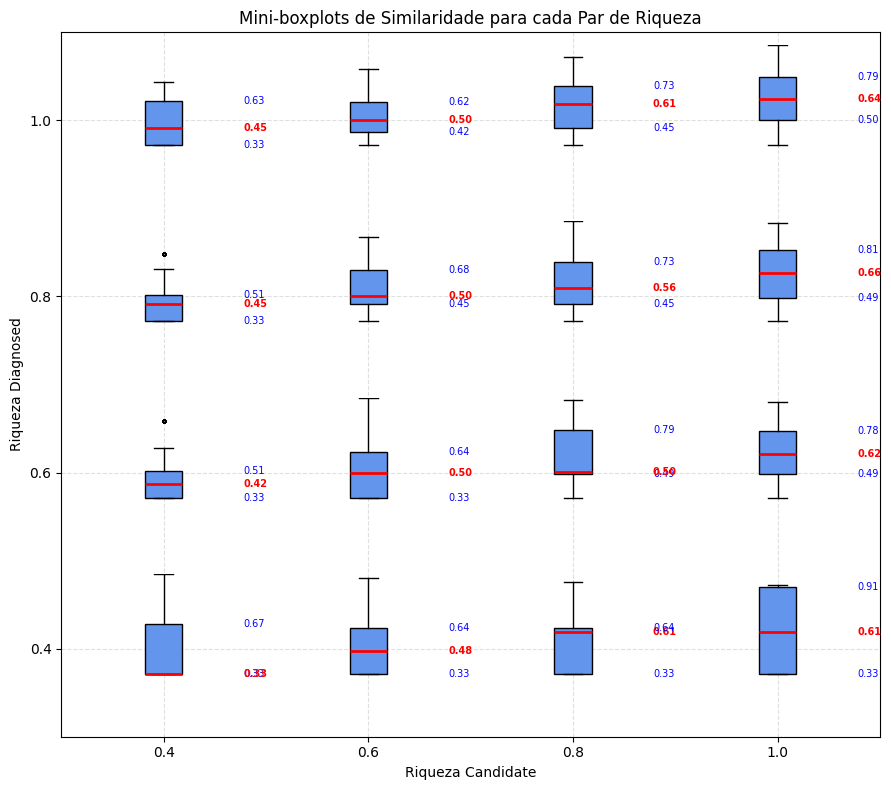

In [66]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(9, 8))

unique_x = sorted(df['riqueza_candidate'].unique())
unique_y = sorted(df['riqueza_diagnosed'].unique())

width = 1.50
height = 1.50

ax.set_xticks(unique_x)
ax.set_yticks(unique_y)
ax.grid(True, which='both', linestyle='--', alpha=0.4)
ax.set_xlim(min(unique_x)-0.1, max(unique_x)+0.1)
ax.set_ylim(min(unique_y)-0.1, max(unique_y)+0.1)
ax.set_xlabel('Riqueza Candidate')
ax.set_ylabel('Riqueza Diagnosed')
ax.set_title('Mini-boxplots de Similaridade para cada Par de Riqueza')

for x in unique_x:
    for y in unique_y:
        subset = df[(df['riqueza_candidate'] == x) & (df['riqueza_diagnosed'] == y)]
        if not subset.empty:
            axins = inset_axes(
                ax, width=width, height=height,
                loc='center',
                bbox_to_anchor=(x, y),
                bbox_transform=ax.transData,
                borderpad=0,
            )
            # Boxplot vertical
            axins.boxplot(
                subset['similarity_result'],
                vert=True,
                patch_artist=True,
                boxprops=dict(facecolor='cornflowerblue', color='k', linewidth=1),
                medianprops=dict(color='red', linewidth=2),
                whiskerprops=dict(color='k'),
                capprops=dict(color='k'),
                flierprops=dict(marker='o', markersize=2, color='gray', alpha=0.6)
            )
            axins.set_xlim(0.7, 1.3)
            axins.set_ylim(0, 1)
            axins.axis('off')

            # Calcula os quartis
            q1 = np.percentile(subset['similarity_result'], 25)
            mediana = np.percentile(subset['similarity_result'], 50)
            q3 = np.percentile(subset['similarity_result'], 75)

            # Adiciona os valores dos quartis como labels ao lado do boxplot
            axins.text(1.32, q1, f"{q1:.2f}", va='center', ha='left', fontsize=7, color='blue')
            axins.text(1.32, mediana, f"{mediana:.2f}", va='center', ha='left', fontsize=7, color='red', fontweight='bold')
            axins.text(1.32, q3, f"{q3:.2f}", va='center', ha='left', fontsize=7, color='blue')

plt.tight_layout()
plt.show()


In [67]:
import plotly.subplots as sp
import plotly.graph_objects as go

unique_x = sorted(df['riqueza_candidate'].unique())
unique_y = sorted(df['riqueza_diagnosed'].unique())

fig = sp.make_subplots(
    rows=len(unique_y), cols=len(unique_x),
    shared_xaxes=False, shared_yaxes=False,
    horizontal_spacing=0.02, vertical_spacing=0.04,
    subplot_titles=[f"Cand={x} | Diag={y}" for y in unique_y for x in unique_x]
)

for i, y in enumerate(unique_y):
    for j, x in enumerate(unique_x):
        subset = df[(df['riqueza_candidate'] == x) & (df['riqueza_diagnosed'] == y)]
        if not subset.empty:
            fig.add_trace(
                go.Box(
                    y=subset['similarity_result'],
                    boxpoints='outliers',
                    marker_color='cornflowerblue',
                    line_color='black',
                    fillcolor='cornflowerblue',
                    name=f'({x}, {y})',
                    showlegend=False,
                    width=0.6
                ),
                row=i+1, col=j+1
            )
            # Quartis: Plotly mostra como linhas do boxplot!

fig.update_layout(
    height=250*len(unique_y), width=250*len(unique_x),
    title_text='Boxplots de Similaridade para cada Par de Riqueza (Plotly Subplots)',
)
fig.update_yaxes(range=[0, 1])  # Fixa o eixo y de 0 a 1
fig.show()


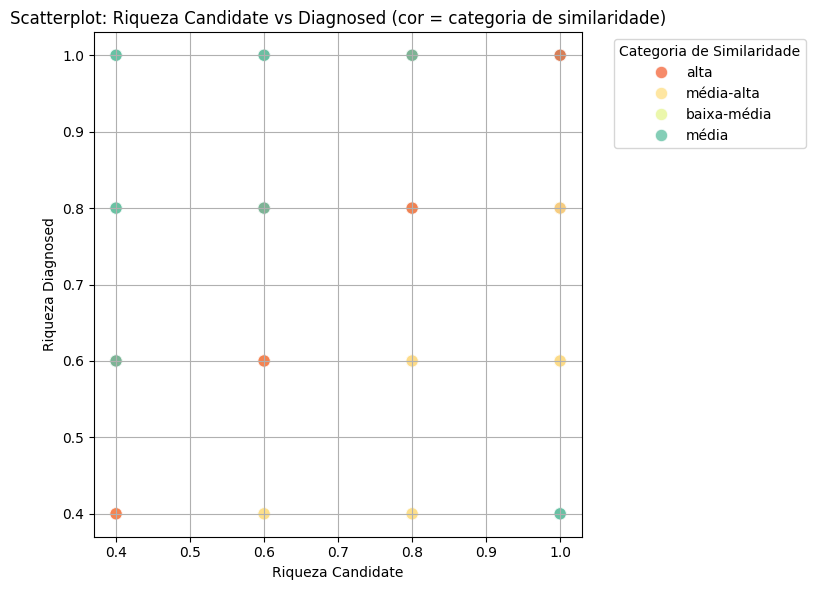

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x='riqueza_candidate',
    y='riqueza_diagnosed',
    hue='categoria_similaridade',
    palette='Spectral',
    s=80,  # tamanho do ponto
    alpha=0.8
)
plt.xlabel('Riqueza Candidate')
plt.ylabel('Riqueza Diagnosed')
plt.title('Scatterplot: Riqueza Candidate vs Diagnosed (cor = categoria de similaridade)')
plt.legend(title='Categoria de Similaridade', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


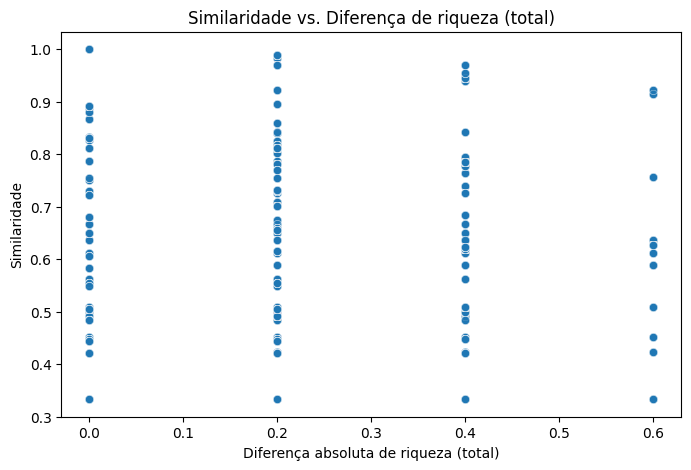

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Diferença absoluta entre as riquezas totais
df['diff_riqueza_total'] = (df['riqueza_diagnosed'] - df['riqueza_candidate']).abs()

plt.figure(figsize=(8, 5))
sns.scatterplot(x='diff_riqueza_total', y='similarity_result', data=df, alpha=0.6)
plt.xlabel('Diferença absoluta de riqueza (total)')
plt.ylabel('Similaridade')
plt.title('Similaridade vs. Diferença de riqueza (total)')
plt.show()


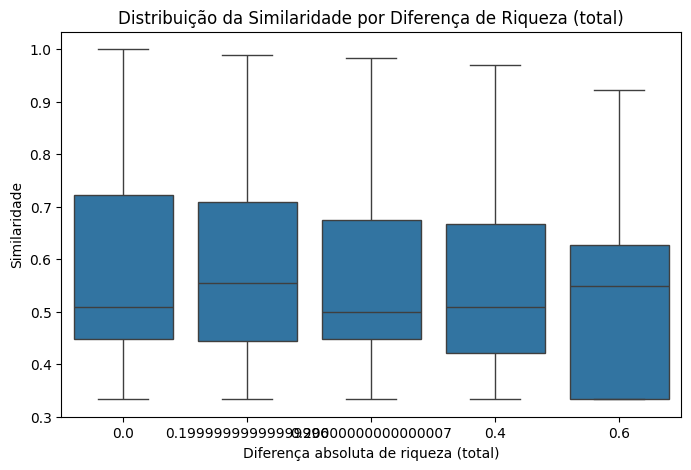

In [33]:
plt.figure(figsize=(8,5))
sns.boxplot(x='diff_riqueza_total', y='similarity_result', data=df)
plt.xlabel('Diferença absoluta de riqueza (total)')
plt.ylabel('Similaridade')
plt.title('Distribuição da Similaridade por Diferença de Riqueza (total)')
plt.show()


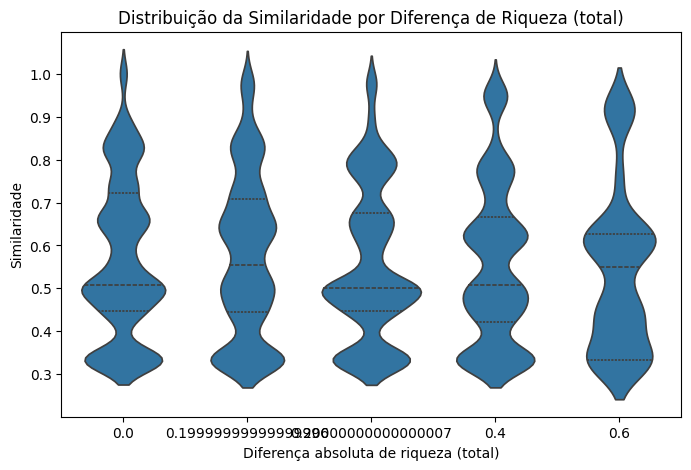

In [34]:
plt.figure(figsize=(8,5))
sns.violinplot(x='diff_riqueza_total', y='similarity_result', data=df, inner='quartile')
plt.xlabel('Diferença absoluta de riqueza (total)')
plt.ylabel('Similaridade')
plt.title('Distribuição da Similaridade por Diferença de Riqueza (total)')
plt.show()


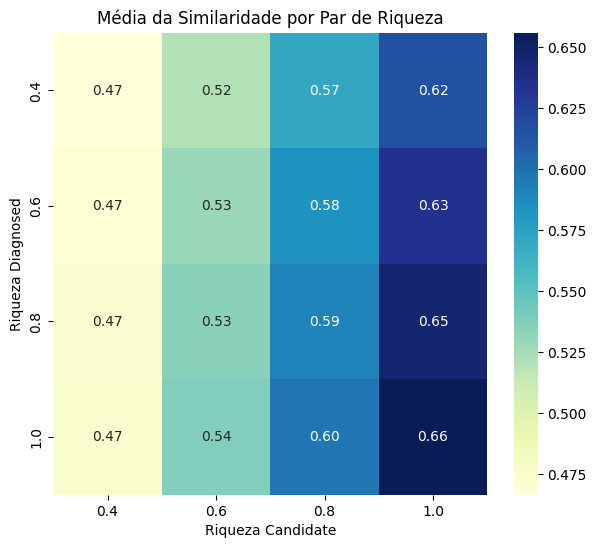

In [35]:
pivot = df.pivot_table(
    index='riqueza_diagnosed', 
    columns='riqueza_candidate', 
    values='similarity_result', 
    aggfunc='mean'
)

plt.figure(figsize=(7,6))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap='YlGnBu')
plt.xlabel('Riqueza Candidate')
plt.ylabel('Riqueza Diagnosed')
plt.title('Média da Similaridade por Par de Riqueza')
plt.show()


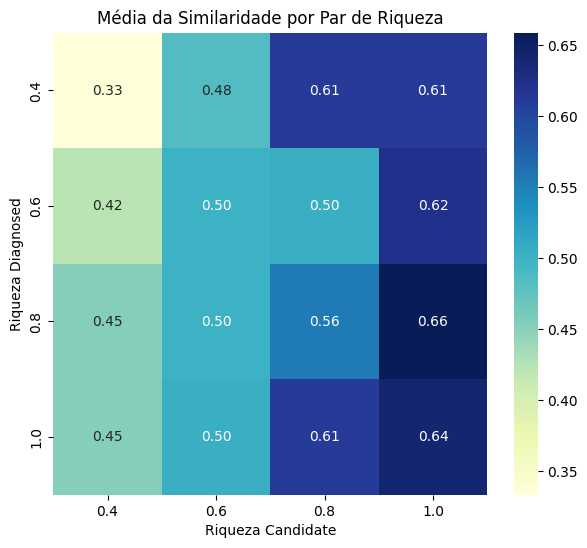

In [37]:
pivot = df.pivot_table(
    index='riqueza_diagnosed', 
    columns='riqueza_candidate', 
    values='similarity_result', 
    aggfunc='median'
)

plt.figure(figsize=(7,6))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap='YlGnBu')
plt.xlabel('Riqueza Candidate')
plt.ylabel('Riqueza Diagnosed')
plt.title('Média da Similaridade por Par de Riqueza')
plt.show()

In [40]:
import plotly.graph_objects as go

# Dados do seu pivot já ordenado
x = pivot_surface.columns.values      # eixo das colunas
y = pivot_surface.index.values        # eixo dos índices
z = pivot_surface.values              # matriz de similaridade

fig = go.Figure(data=[
    go.Surface(
        z=z,
        x=x,
        y=y,
        colorscale='YlGnBu',
        colorbar=dict(title='Similaridade'),
        showscale=True,
        contours={
            "x": {"show": True, "start": min(x), "end": max(x), "size": 0.2, "color":"black"},
            "y": {"show": True, "start": min(y), "end": max(y), "size": 0.2, "color":"black"},
            "z": {"show": True, "start": z.min(), "end": z.max(), "size": 0.05, "color":"black"},
        },
        opacity=0.98
    )
])

fig.update_layout(
    title='Surface 3D com Linhas de Rede - Similaridade por Par de Riqueza',
    scene=dict(
        xaxis_title='Riqueza Candidate',
        yaxis_title='Riqueza Diagnosed',
        zaxis_title='Similaridade (mediana)'
    ),
    autosize=True,
    margin=dict(l=50, r=50, b=65, t=90),
)

fig.show()


In [ ]:
------------------

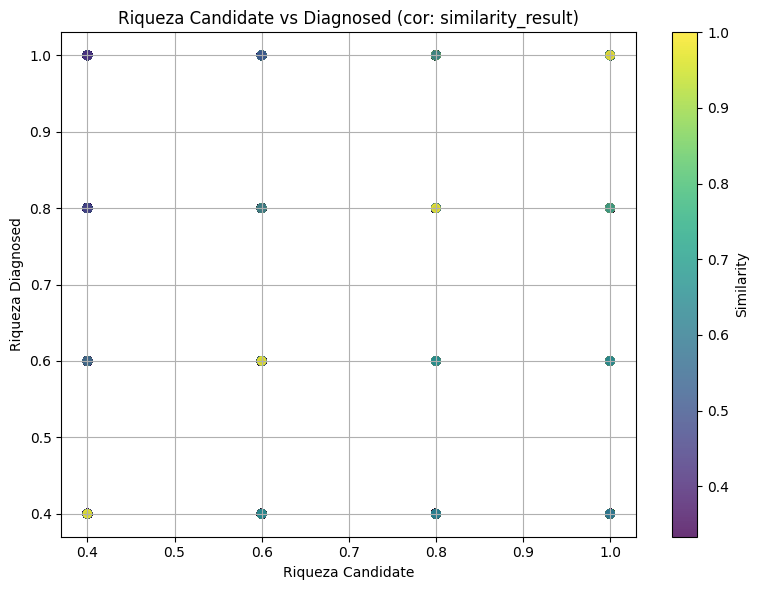

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# Agora: eixo X = riqueza_candidate, eixo Y = riqueza_diagnosed
scatter = plt.scatter(
    df['riqueza_candidate'],
    df['riqueza_diagnosed'],
    c=df['similarity_result'],
    cmap='viridis',
    alpha=0.8
)

plt.xlabel('Riqueza Candidate')
plt.ylabel('Riqueza Diagnosed')
plt.title('Riqueza Candidate vs Diagnosed (cor: similarity_result)')
plt.colorbar(scatter, label='Similarity')
plt.grid(True)
plt.tight_layout()
plt.show()


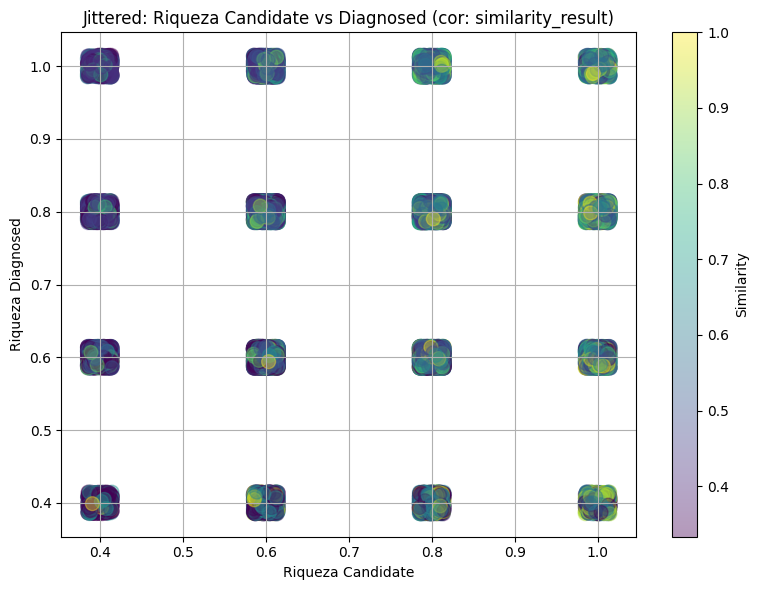

In [20]:
import plotly.graph_objs as go
import numpy as np
import pandas as pd

# 1. Pivot com a média de similaridade para cada grid
pivot = df.pivot_table(
    index='riqueza_diagnosed',
    columns='riqueza_candidate',
    values='similarity_result',
    aggfunc='mean'
)

# 2. Garante ordem crescente dos eixos
x = np.array(pivot.columns)
y = np.array(pivot.index)
z = np.array(pivot.values)

# 3. Cria o gráfico de superfície
fig = go.Figure(
    data=[go.Surface(
        z=z, x=x, y=y, colorscale='Viridis', colorbar=dict(title='Similarity')
    )]
)

fig.update_layout(
    title='Surface: Similaridade Média por Riqueza Diagnosed × Candidate',
    scene = dict(
        xaxis_title='Riqueza Candidate',
        yaxis_title='Riqueza Diagnosed',
        zaxis_title='Similarity'
    ),
    autosize=False,
    width=700,
    height=600,
    margin=dict(l=60, r=30, b=65, t=90)
)

fig.show()


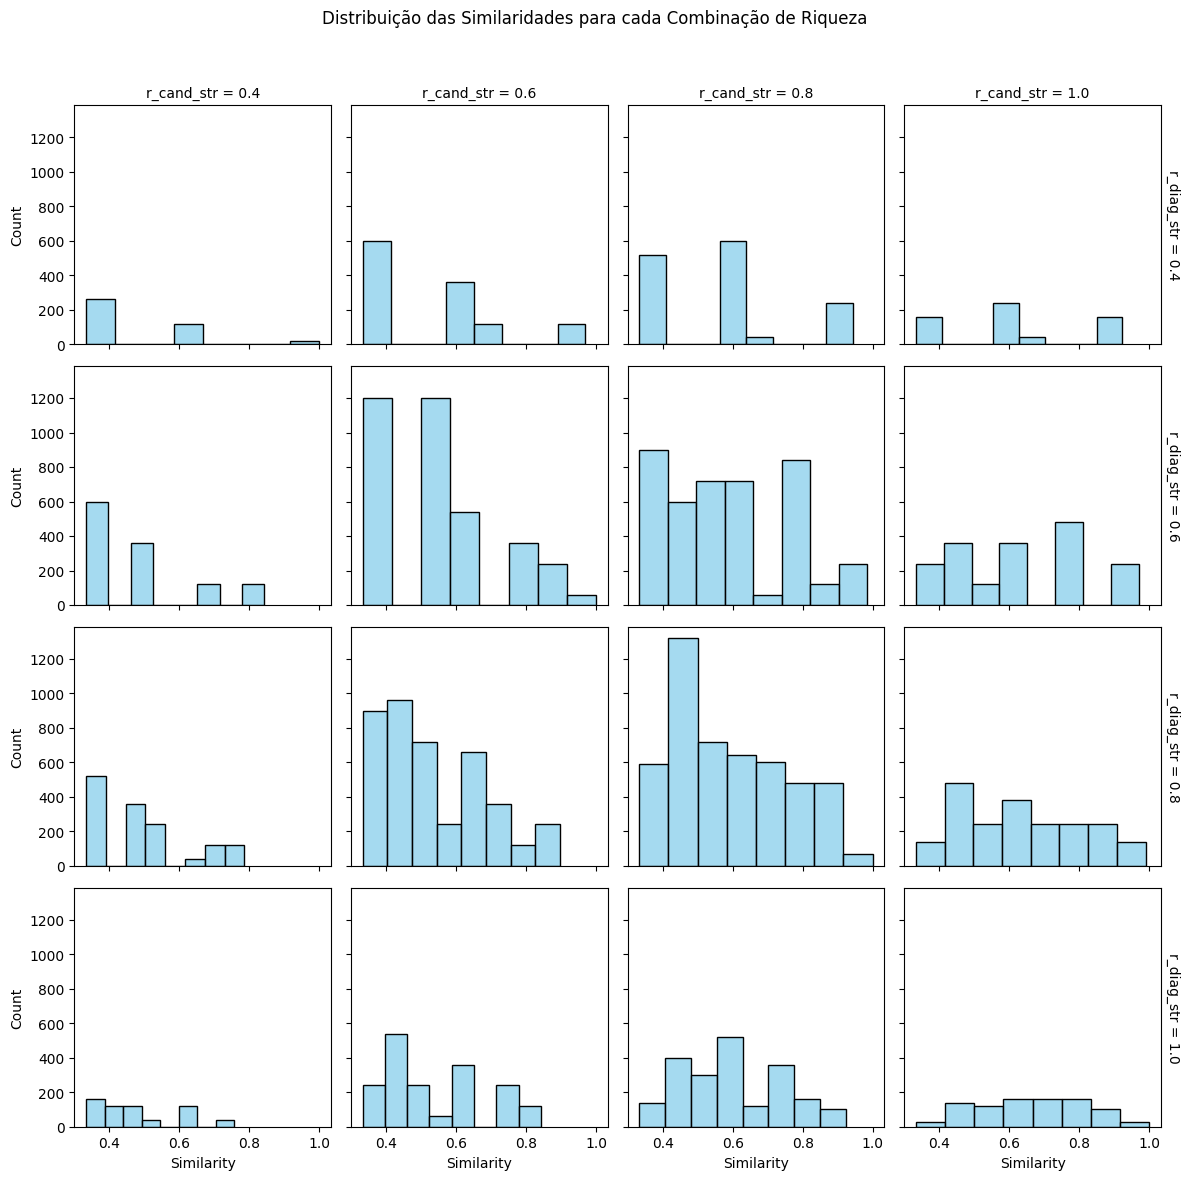

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Converte para string para o grid funcionar
df['r_diag_str'] = df['riqueza_diagnosed'].astype(str)
df['r_cand_str'] = df['riqueza_candidate'].astype(str)

g = sns.FacetGrid(
    df,
    row='r_diag_str',
    col='r_cand_str',
    margin_titles=True,
    despine=False
)
g.map(sns.histplot, 'similarity_result', bins=8, color='skyblue')
g.set_axis_labels('Similarity', 'Count')
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Distribuição das Similaridades para cada Combinação de Riqueza")
plt.show()


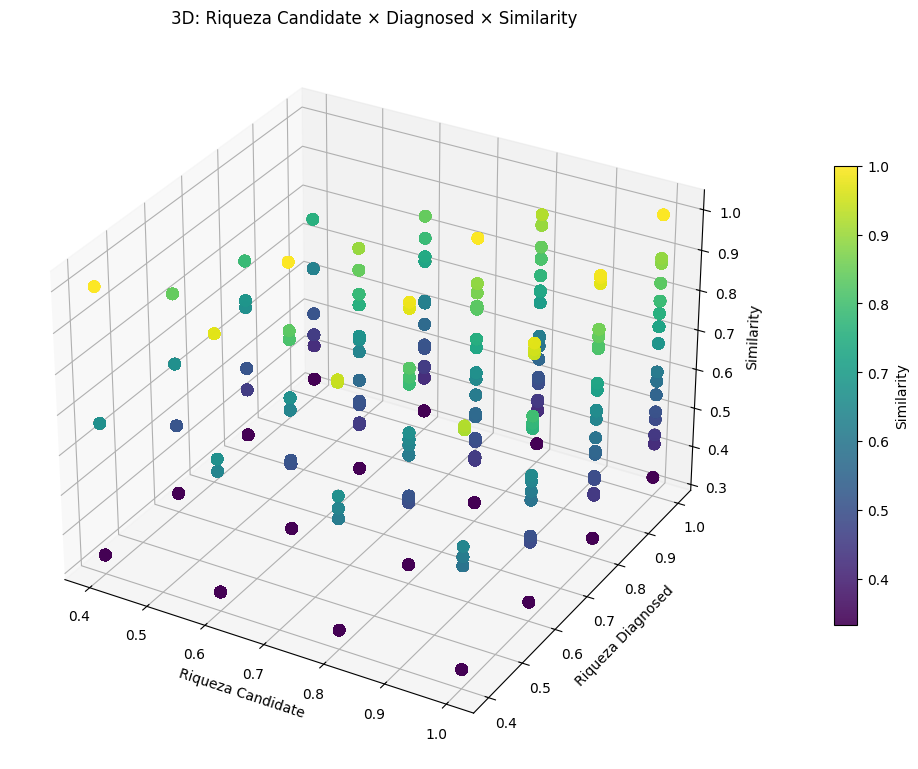

In [13]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # Necessário para 3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter 3D
p = ax.scatter(
    df['riqueza_candidate'],
    df['riqueza_diagnosed'],
    df['similarity_result'],
    c=df['similarity_result'],
    cmap='viridis',
    s=60,
    alpha=0.9
)

ax.set_xlabel('Riqueza Candidate')
ax.set_ylabel('Riqueza Diagnosed')
ax.set_zlabel('Similarity')
ax.set_title('3D: Riqueza Candidate × Diagnosed × Similarity')

fig.colorbar(p, ax=ax, shrink=0.6, pad=0.1, label='Similarity')
plt.tight_layout()
plt.show()


C:\Users\lucas_alves\AppData\Local\Temp\ipykernel_98464\2269424013.py:35: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior

C:\Users\lucas_alves\AppData\Local\Temp\ipykernel_98464\2269424013.py:36: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior

C:\Users\lucas_alves\AppData\Local\Temp\ipykernel_98464\2269424013.py:37: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior



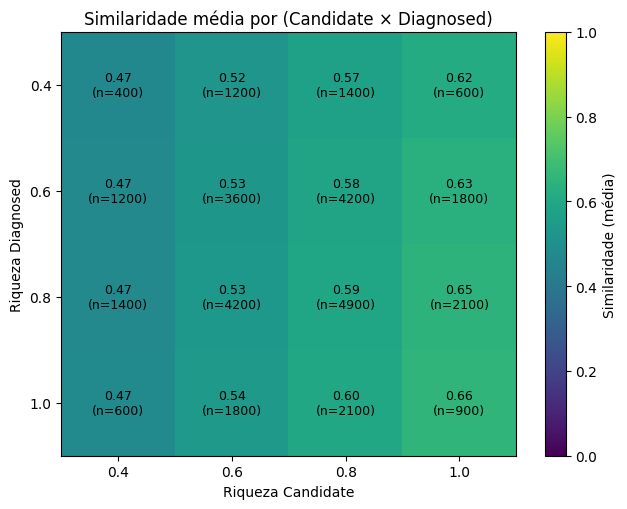

C:\Users\lucas_alves\AppData\Local\Temp\ipykernel_98464\2269424013.py:75: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.

C:\Users\lucas_alves\AppData\Local\Temp\ipykernel_98464\2269424013.py:83: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



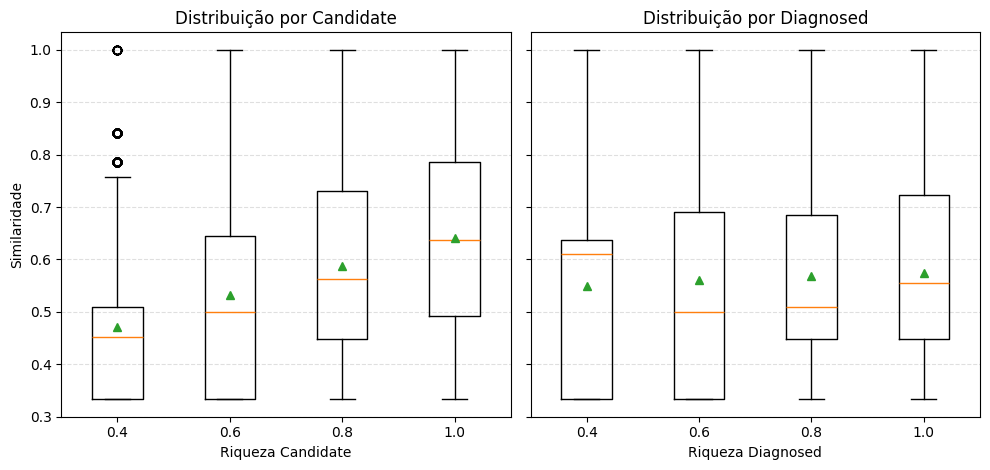

ValueError: Unable to determine Axes to steal space for Colorbar. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.

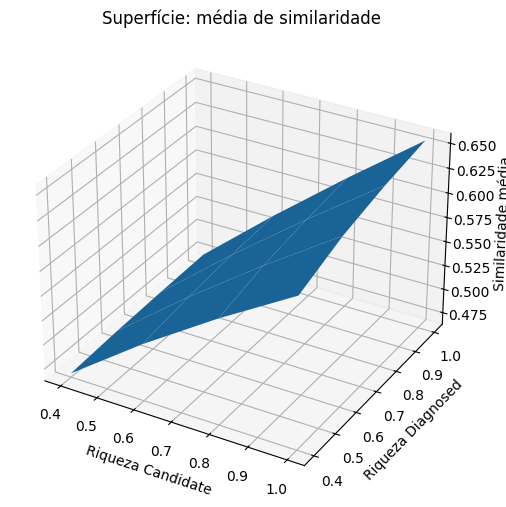

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1) Preparação dos dados
# =========================
# Renomeia colunas que possam vir com "# " no início
rename_map = {}
for col in list(df.columns):
    col_clean = col.strip().lstrip('#').strip().lower().replace(' ', '_')
    rename_map[col] = col_clean
df = df.rename(columns=rename_map)

# Espera-se agora ter:
# df.columns -> ['similarity_result', 'riqueza_diagnosed', 'riqueza_candidate']
col_sim = 'similarity_result'
col_rc  = 'riqueza_candidate'
col_rd  = 'riqueza_diagnosed'

# Normaliza tipos
df[col_rc] = df[col_rc].astype(float)
df[col_rd] = df[col_rd].astype(float)
df[col_sim] = df[col_sim].astype(float)

# Define ordem categórica fixa
ordem = [0.4, 0.6, 0.8, 1.0]
df[col_rc] = pd.Categorical(df[col_rc], categories=ordem, ordered=True)
df[col_rd] = pd.Categorical(df[col_rd], categories=ordem, ordered=True)

# =========================
# 2) Tabela de métricas por célula
# =========================
# média, mediana, contagem (você pode trocar por outra medida, p.ex. p95)
pivot_mean = df.pivot_table(index=col_rd, columns=col_rc, values=col_sim, aggfunc='mean')
pivot_count = df.pivot_table(index=col_rd, columns=col_rc, values=col_sim, aggfunc='count')
pivot_median = df.pivot_table(index=col_rd, columns=col_rc, values=col_sim, aggfunc='median')

# =========================
# 3) Heatmap (média) com contagem anotada
# =========================
fig, ax = plt.subplots(figsize=(6.5, 5.2))
im = ax.imshow(pivot_mean.values.astype(float), origin='upper', aspect='auto', vmin=0, vmax=1)

# Eixos/rotulagem
ax.set_xticks(range(len(ordem)))
ax.set_yticks(range(len(ordem)))
ax.set_xticklabels(ordem)
ax.set_yticklabels(ordem)
ax.set_xlabel('Riqueza Candidate')
ax.set_ylabel('Riqueza Diagnosed')
ax.set_title('Similaridade média por (Candidate × Diagnosed)')

# Anota contagem e média por célula
for i in range(pivot_mean.shape[0]):
    for j in range(pivot_mean.shape[1]):
        mean_val = pivot_mean.values[i, j]
        cnt_val = int(pivot_count.values[i, j]) if not np.isnan(pivot_count.values[i, j]) else 0
        txt = f"{mean_val:.2f}\n(n={cnt_val})" if not np.isnan(mean_val) else "–"
        ax.text(j, i, txt, ha='center', va='center', fontsize=9)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Similaridade (média)')

plt.tight_layout()
plt.show()

# =========================
# 4) Boxplots marginais
# =========================
fig, axes = plt.subplots(1, 2, figsize=(10, 4.8), sharey=True)

# Boxplot por riqueza_candidate
data_by_rc = [df.loc[df[col_rc] == r, col_sim].values for r in ordem]
axes[0].boxplot(data_by_rc, labels=ordem, showmeans=True)
axes[0].set_xlabel('Riqueza Candidate')
axes[0].set_ylabel('Similaridade')
axes[0].set_title('Distribuição por Candidate')
axes[0].grid(True, axis='y', linestyle='--', alpha=0.4)

# Boxplot por riqueza_diagnosed
data_by_rd = [df.loc[df[col_rd] == r, col_sim].values for r in ordem]
axes[1].boxplot(data_by_rd, labels=ordem, showmeans=True)
axes[1].set_xlabel('Riqueza Diagnosed')
axes[1].set_title('Distribuição por Diagnosed')
axes[1].grid(True, axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# =========================
# 5) Superfície 3D (Z = média de similaridade)
# =========================
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

X_vals = np.array(ordem, dtype=float)
Y_vals = np.array(ordem, dtype=float)
Z = pivot_mean.values.astype(float)

# Interpolação simples (opcional): preenche NaN com mediana geral
if np.isnan(Z).any():
    Z = np.where(np.isnan(Z), np.nanmedian(df[col_sim].values), Z)

X, Y = np.meshgrid(X_vals, Y_vals)

fig = plt.figure(figsize=(7.5, 6.0))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z, linewidth=0, antialiased=True)
ax.set_xlabel('Riqueza Candidate')
ax.set_ylabel('Riqueza Diagnosed')
ax.set_zlabel('Similaridade média')
ax.set_title('Superfície: média de similaridade')

# Barra de cores (usa os valores de Z achatados)
m = plt.cm.ScalarMappable()
m.set_array(Z.ravel())
plt.colorbar(m, shrink=0.6, pad=0.1, label='Similaridade (média)')

plt.tight_layout()
plt.show()

# =========================
# 6) (Opcional) Boxplots por par (Candidate×Diagnosed)
# =========================
# Útil para ver variabilidade dentro de cada célula
pairs = df.groupby([col_rc, col_rd])[col_sim].apply(list)
labels = [f"C{c} | D{d}" for (c, d) in pairs.index]
values = list(pairs.values)

plt.figure(figsize=(max(8, 0.5*len(values)+4), 5.2))
plt.boxplot(values, labels=labels, showmeans=True)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Similaridade')
plt.title('Distribuição por par (Candidate × Diagnosed)')
plt.grid(True, axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


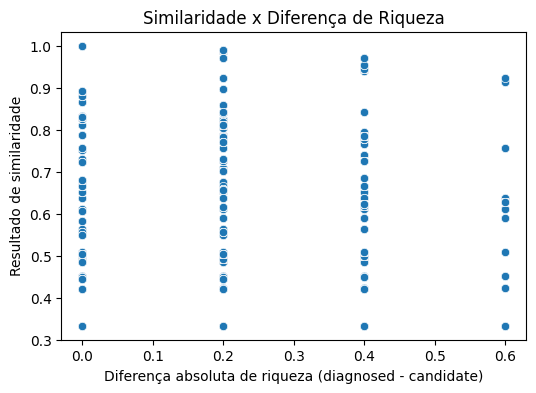

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calcular diferença absoluta entre as riquezas
df['diff'] = abs(df['riqueza_diagnosed'] - df['riqueza_candidate'])

# Scatter plot de similaridade vs diferença de riqueza
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x='diff', y='similarity_result')
plt.xlabel('Diferença absoluta de riqueza (diagnosed - candidate)')
plt.ylabel('Resultado de similaridade')
plt.title('Similaridade x Diferença de Riqueza')
plt.show()


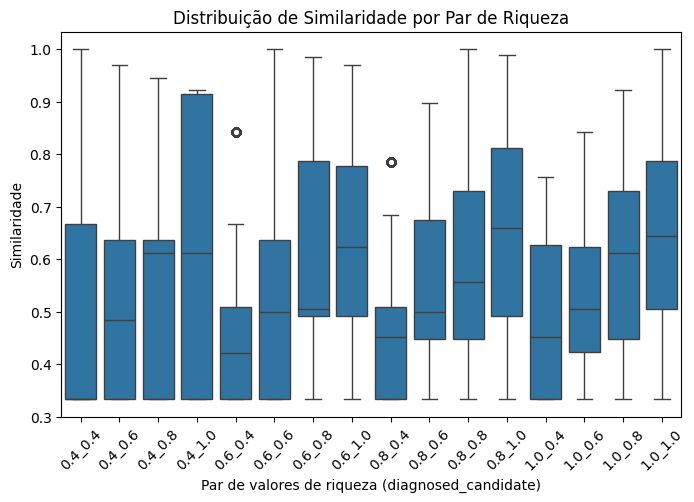

In [26]:
# Criar coluna identificando o par de riquezas
df['pair'] = df['riqueza_diagnosed'].astype(str) + '_' + df['riqueza_candidate'].astype(str)

# Boxplot de similaridade para cada par de riqueza
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='pair', y='similarity_result')
plt.xticks(rotation=45)
plt.xlabel('Par de valores de riqueza (diagnosed_candidate)')
plt.ylabel('Similaridade')
plt.title('Distribuição de Similaridade por Par de Riqueza')
plt.show()


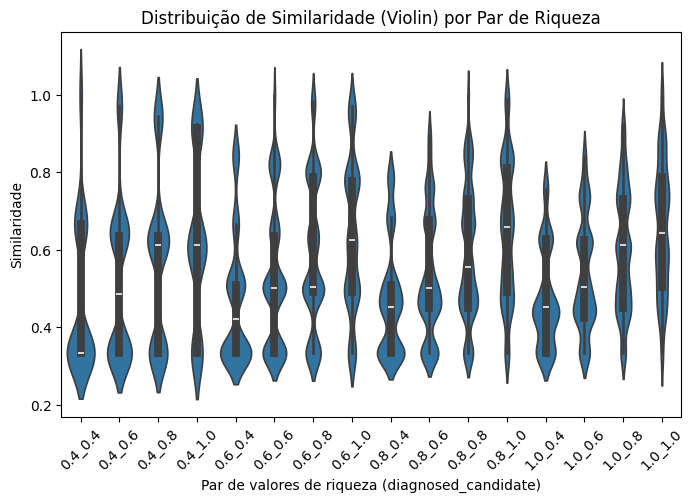

In [27]:
# Violin plot de similaridade para cada par de riqueza
plt.figure(figsize=(8,5))
sns.violinplot(data=df, x='pair', y='similarity_result')
plt.xticks(rotation=45)
plt.xlabel('Par de valores de riqueza (diagnosed_candidate)')
plt.ylabel('Similaridade')
plt.title('Distribuição de Similaridade (Violin) por Par de Riqueza')
plt.show()


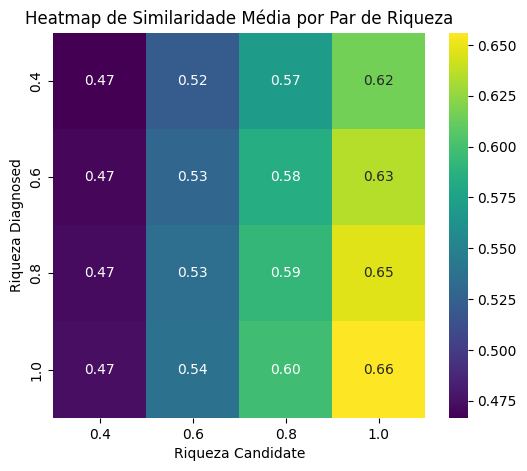

In [28]:
# Pivot table de similaridade média por combinação de riquezas
heat_data = df.pivot_table(
    index='riqueza_diagnosed', 
    columns='riqueza_candidate', 
    values='similarity_result', 
    aggfunc='mean'
)

# Plot do heatmap
plt.figure(figsize=(6,5))
sns.heatmap(heat_data, annot=True, fmt=".2f", cmap='viridis')
plt.xlabel('Riqueza Candidate')
plt.ylabel('Riqueza Diagnosed')
plt.title('Heatmap de Similaridade Média por Par de Riqueza')
plt.show()
